# 低速风洞Reynolds数范围论证


*低速风洞试验段温度计量特性对雷诺数包线的影响研究*

*陈钦，赵少美，黄志阳*
*中国空气动力研究与发展中心 设备设计与测试技术研究所*

*2025-08-08 四川·绵阳 航空航天测试装备原位检测技术学术研讨会*

---

## 交流内容

本次交流主要涉及以下方面：
- **飞行装备**：用于飞行控制的气动模型
- **风洞试验**：通过缩比模型获得飞行器的气动特性
- **风洞设计**：风洞如何模拟相似数
- **计量保障**：可计量性设计，试验数据计量，风洞计量


## 飞行力学与雷诺数 (Re)

### 雷诺数 (Re)
雷诺数是流体力学中最重要的无量纲数之一，它定义为流体惯性力与粘性力的比值。

$$
Re = \frac{\rho v L}{\mu}
$$

其中：
- $\rho$: 流体密度
- $v$: 流速
- $L$: 特征长度
- $\mu$: 流体动力粘度

雷诺数对飞行器的气动特性有重要影响。

![奥斯本·雷诺兹](imgs/reynolds-the-person.jfif)
*英国物理学家奥斯本·雷诺兹 (Osborne Reynolds)*


### 飞行力学基础

飞行力学的核心是根据初始条件和作用在飞行器上的力/力矩，预测其运动轨迹。

- **牛顿第二定律**:
  - 质心运动: $\vec{F} = m\vec{a}$
  - 绕质心转动: $\vec{M} = I\dot{\vec{\omega}}$

作用在飞行器上的力主要包括重力、发动机推力以及气动力。

$$
\begin{cases}
m \frac{d\vec{v}}{dt} = \vec{F} \\
I \frac{d\vec{H}}{dt} = \vec{M}
\end{cases}
$$

![飞行器体坐标系](imgs/fd-body-axis.png)


### 飞行器气动力的量纲分析

飞行器所受的气动力/力矩是一个复杂的函数，依赖于众多变量。通常将其分解为三力三矩：
- **三力**: 阻力 ($R_D$), 升力 ($R_L$), 侧向力 ($R_Y$)
- **三矩**: 滚动力矩 ($M_l$), 偏航力矩 ($M_n$), 俯仰力矩 ($M_m$)

其带量纲的表达式形式为：

$$
R = f(\alpha, \beta, v, L, \dots, \rho, P, \mu, \dots)
$$

这是一个涉及超过16个自变量的函数，包括几何参数、运动参数、材料参数和流体参数。

通过量纲分析，这个复杂的关系可以简化为无量纲气动系数与一系列无量纲相似数之间的关系：

$$
C_R = \frac{R}{\frac{1}{2}\rho v^2 L^2} = F(\alpha, \beta, Ma, Re, \dots)
$$

对于低速飞行器（$Ma < 0.3$），马赫数的影响可以忽略，气动模型主要依赖于迎角 $\alpha$、侧滑角 $\beta$ 和雷诺数 $Re$。

$$
C_{\text{aerodynamic}} = 
\begin{pmatrix}
C_D(\alpha, \beta, Re) \\
C_L(\alpha, \beta, Re) \\
C_Y(\alpha, \beta, Re) \\
C_l(\alpha, \beta, Re) \\
C_n(\alpha, \beta, Re) \\
C_m(\alpha, \beta, Re)
\end{pmatrix}
$$


### 雷诺数对飞行器的影响

雷诺数对不同尺寸和速度的飞行器翼型气动特性（如最大升阻比）有显著影响。

![Re数对不同翼型最大升阻比的影响](imgs/reynolds.png)


## 典型飞行器参数与飞行包线

### 典型飞行器参数

#### Cessna 172 (轻型飞机)
- **最大速度**: 230 km/h
- **翼展**: 11.00 m

#### Boeing 747-400 (大型客机)
- **最大速度**: 917 km/h
- **翼展**: 59.64 m

### 飞机飞行包线

飞行包线定义了飞机在高度、速度等方面的安全运行边界。

![典型亚声速飞机飞行包线](imgs/vh_envelope.png)

根据飞行包线，我们可以计算出飞机在不同飞行阶段（起飞、爬升、巡航、下降、着陆）对应的雷诺数范围。

$$
Re = \frac{\rho(H) \cdot v \cdot L}{\mu(H)}
$$

其中，大气密度 $\rho$ 和粘性 $\mu$ 都是飞行高度 $H$ 的函数。


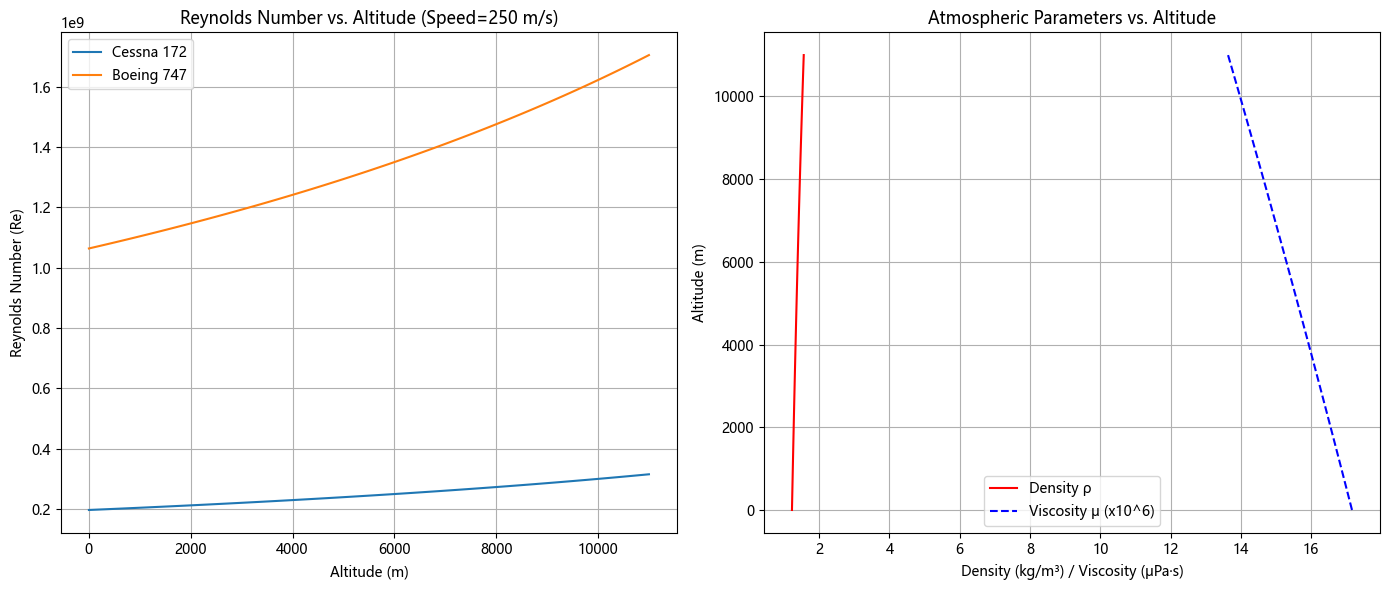

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define Standard Atmosphere Model (Simplified, Troposphere only) ---
def atmosphere_model(H):
    """
    Calculate temperature, pressure, density, and viscosity based on altitude (simplified model)
    H: Altitude (m)
    """
    T0 = 288.15  # Sea level temperature (K)
    P0 = 101325  # Sea level pressure (Pa)
    L = 0.0065   # Temperature lapse rate (K/m)
    R = 287.05   # Gas constant (J/(kg·K))
    g = 9.80665  # Gravitational acceleration (m/s^2)
    
    # Temperature
    T = T0 - L * H
    
    # Pressure
    P = P0 * (1 - L * H / T0)**(g * 0.0289644 / (R * L))
    
    # Density
    rho = P / (R * T)
    
    # Viscosity (Sutherland's Law)
    mu0 = 1.716e-5 # Sea level viscosity (Pa·s)
    S = 110.4      # Sutherland's constant (K)
    mu = mu0 * (T / T0)**1.5 * (T0 + S) / (T + S)
    
    return T, P, rho, mu

# --- 2. Calculate Reynolds Number ---
def calculate_reynolds(v, L, H):
    """
    Calculate Reynolds number for given flight conditions
    v: Velocity (m/s)
    L: Characteristic length (m)
    H: Altitude (m)
    """
    _, _, rho, mu = atmosphere_model(H)
    return rho * v * L / mu

# --- 3. Example Calculation and Plotting ---
H_range = np.linspace(0, 11000, 100) # 0 to 11km altitude
v_cruise = 250 # Cruise speed (m/s, approx. 900 km/h)
L_cessna = 11.0
L_boeing = 59.6

Re_cessna = [calculate_reynolds(v_cruise, L_cessna, H) for H in H_range]
Re_boeing = [calculate_reynolds(v_cruise, L_boeing, H) for H in H_range]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Re vs. Altitude
ax1.plot(H_range, Re_cessna, label='Cessna 172')
ax1.plot(H_range, Re_boeing, label='Boeing 747')
ax1.set_title(f'Reynolds Number vs. Altitude (Speed={v_cruise} m/s)')
ax1.set_xlabel('Altitude (m)')
ax1.set_ylabel('Reynolds Number (Re)')
ax1.grid(True)
ax1.legend()
ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

# Atmospheric Parameters vs. Altitude
T_vals, P_vals, rho_vals, mu_vals = atmosphere_model(H_range)
ax2.plot(rho_vals, H_range, 'r-', label='Density ρ')
ax2.plot(mu_vals*1e6, H_range, 'b--', label='Viscosity μ (x10^6)') # Scaled for visibility
ax2.set_title('Atmospheric Parameters vs. Altitude')
ax2.set_xlabel('Density (kg/m³) / Viscosity (μPa·s)')
ax2.set_ylabel('Altitude (m)')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

## 低速风洞与雷诺数模拟

### 风洞试验基本原理

风洞试验通过在静止的缩比模型上吹风，来模拟飞行器在空中的飞行状态。依据运动相对性原理，模型所受的气动力可以换算为真实飞行条件下的气动力。

为了保证试验结果的有效性，风洞试验需要模拟真实飞行的相似数，其中最重要的就是雷诺数 $Re$ 和马赫数 $Ma$。

$$
Re_{\text{windtunnel}} = Re_{\text{flight}}
$$

### 如何在风洞中提高雷诺数？

$$
Re = \frac{\rho v L_{\text{model}}}{\mu}
$$

- **增大模型尺寸 $L_{\text{model}}$**: 受限于风洞试验段尺寸，通常模型尺寸约为试验段等效直径的1/10。
- **增大风速 $v$**: 对于低速风洞，会受到可压缩效应的限制 ($Ma < 0.3$)。
- **改变气体介质**:
  - **增大气体密度 $\rho$**: 例如使用重气体或对风洞进行增压。
  - **减小气体粘性 $\mu$**: 例如使用低温风洞（液氮冷却）。

在工程实践中，通常是在风洞可达到的 $Re$ 数范围内进行试验，然后通过外插算法将数据修正到真实飞行的 $Re$ 数。


### 风洞设计流程与雷诺数包线

风洞的总体气动设计需要首先确定其核心指标，包括雷诺数模拟能力。

![风洞设计流程](imgs/process.png)
*GJB 11283.1-2023规范的风洞设计过程*

设计流程确定了试验段尺寸、速度范围以及运行的温压条件，这些共同决定了风洞的雷诺数包线。

#### 风洞雷诺数计算

风洞的雷诺数包线由其速度、压力和温度的运行范围决定。


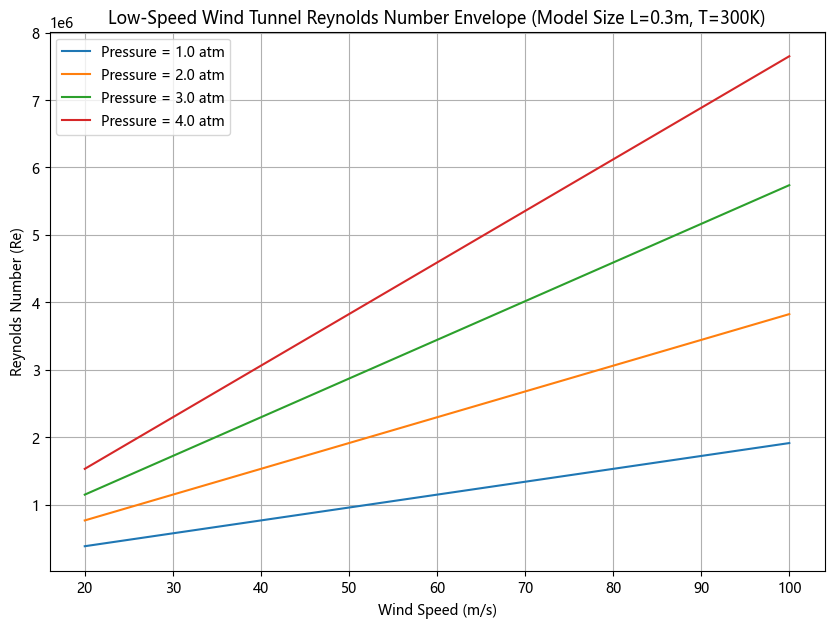

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define Wind Tunnel Parameters ---
# Assuming a low-speed pressurized wind tunnel
D_test_section = 3.0  # Test section diameter (m)
L_model = D_test_section / 10 # Typical model size (m)

# Operating parameter ranges
V_range = np.linspace(20, 100, 50)  # Velocity range (m/s)
P_abs_range = np.linspace(1, 4, 4)   # Absolute pressure range (atm)
T_const = 300 # Assuming constant operating temperature (K)

# --- 2. Calculate Re Number at Different Pressures ---
def calculate_re_wind_tunnel(v, P_atm, T):
    """
    Calculate Reynolds number in the wind tunnel
    v: Velocity (m/s)
    P_atm: Pressure (atm)
    T: Temperature (K)
    """
    R = 287.05
    P_pa = P_atm * 101325
    rho = P_pa / (R * T)
    
    # Viscosity (Sutherland's Law)
    mu0 = 1.716e-5
    T0 = 273.15
    S = 110.4
    mu = mu0 * (T / T0)**1.5 * (T0 + S) / (T + S)
    
    return rho * v * L_model / mu

# --- 3. Plotting ---
plt.figure(figsize=(10, 7))

for P_atm in P_abs_range:
    Re_values = [calculate_re_wind_tunnel(v, P_atm, T_const) for v in V_range]
    plt.plot(V_range, Re_values, label=f'Pressure = {P_atm} atm')

plt.title(f'Low-Speed Wind Tunnel Reynolds Number Envelope (Model Size L={L_model:.1f}m, T={T_const}K)')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Reynolds Number (Re)')
plt.grid(True)
plt.legend()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.show()

## 结论

- 飞行器的气动特性（特别是低速下）强依赖于雷诺数。
- 风洞试验的核心是模拟真实飞行的相似数，尤其是雷诺数。
- 由于物理和投资限制，在地面设备中完全复现高空高速飞行的雷诺数非常困难。
- 风洞设计通过综合考虑尺寸、速度、压力、温度等因素，来定义其雷诺数模拟能力（即雷诺数包线）。
- 精确的温度、压力等参数的计量是保证雷诺数模拟准确性的基础，直接影响风洞试验数据的质量。